Import Libraries

In [49]:
import pandas as pd
import re
import ast
import numpy as np
import matplotlib.pyplot as plt
from haversine import haversine
import os
import math
import geopandas as gpd
import contextily as ctx
import random
import seaborn as sns
from pathlib import Path
import opendssdirect as dss
from scipy.spatial import cKDTree

# Set default font size to 18
plt.rcParams.update({'font.size': 18})

Load data


In [25]:
EVplanningFolder = "Results4"

os.chdir(r"C:\Users\jingb\Box\EVPlanning_iScience\GridIntegration")
cur_path = os.getcwd()
cur_path

def get_current_path():
    """
    Get the current working directory.
    """
    os.chdir(r"C:\Users\jingb\Box\EVPlanning_iScience\GridIntegration")
    cur_path = os.getcwd()
    return cur_path


In [3]:
AusGridPath = r"D:\AUS"
masterpath = r"scenarios\base_timeseries\opendss_no_loadshapes\Master.dss"
buscoords_path = r"scenarios\base_timeseries\opendss_no_loadshapes\Buscoords.dss"

def compile_dss_files(AusGridPath, masterpath, buscoords_path):
    subGridPath = os.listdir(AusGridPath)
    MasterPaths = [
        os.path.join(AusGridPath, a, masterpath)
        for a in subGridPath
    ]
    BusPaths = [
        os.path.join(AusGridPath, a, buscoords_path)
        for a in subGridPath
    ]
    return MasterPaths, BusPaths, subGridPath

MasterPaths, BusPaths, subGridPath = compile_dss_files(AusGridPath, masterpath, buscoords_path)

In [4]:
BusPaths

['D:\\AUS\\P1R\\scenarios\\base_timeseries\\opendss_no_loadshapes\\Buscoords.dss',
 'D:\\AUS\\P1U\\scenarios\\base_timeseries\\opendss_no_loadshapes\\Buscoords.dss',
 'D:\\AUS\\P2U\\scenarios\\base_timeseries\\opendss_no_loadshapes\\Buscoords.dss',
 'D:\\AUS\\P3U\\scenarios\\base_timeseries\\opendss_no_loadshapes\\Buscoords.dss',
 'D:\\AUS\\P4U\\scenarios\\base_timeseries\\opendss_no_loadshapes\\Buscoords.dss',
 'D:\\AUS\\P5U\\scenarios\\base_timeseries\\opendss_no_loadshapes\\Buscoords.dss']

In [4]:
def check_overall_bus_voltages(bus_names):
    vpu_allbus = {}
    for bus in bus_names:
        dss.Circuit.SetActiveBus(bus)
        v = dss.Bus.puVmagAngle()
        vmag = [v[i] for i in range(0, len(v), 2)]
        n = dss.Bus.Nodes()
        vmag = vmag[:len(n)]
        vmag = [v for i, v in enumerate(vmag) if vmag[i] != 0]
        if vmag:
            vpu_allbus[bus] = min(vmag)
    
    # Find the threshold of Vmin
    vmin_threshold = min(vpu_allbus.values())
    return vpu_allbus, vmin_threshold

# Helper function to check if a load exists
def load_exists(load_name):
    try:
        dss.Loads.Name(load_name)  # Try setting the load active
        return dss.Loads.Name().lower() == load_name.lower()  # Confirm match
    except:
        return False

In [5]:
# case_study_type: 1 for original paper, 2 for case study
def run_case(caseidx, case_study_type=2,regionidx=None,initial_max_capacity=500):
    os.chdir(r"C:\Users\jingb\Box\EVPlanning_iScience\GridIntegration")
    cur_path = os.getcwd()
    # get EV charger station path
    EVcoords_path = r"..\AustinAreabyCity\filtered_file_EV charger station.xlsx" # EV charger station data
    EVData = pd.read_excel(EVcoords_path, usecols=['Latitude', 'Longitude', 'Power', 'Occupancy', 'ChargerNumber'])
    # get bus coordinates path
    Buscoords_path = "allbuscoords.csv" # Bus coordinates data
    BusData = pd.read_csv(Buscoords_path, index_col=None)
    
    if case_study_type == 1:
        EV_optm_exi_path = r"..\df_chargers_existing_extended_0.csv" # planned EV existing in meters
        EV_optm_new_path = r"..\df_chargers_newly_established_0.csv" # planned EV new in meters
        EVplanData1 = pd.read_csv(EV_optm_exi_path, index_col=None)
        EVplanData2 = pd.read_csv(EV_optm_new_path, index_col=None)
        # concatenate the two dataframes EVplanData1 and EVplanData2
    elif case_study_type == 2:
        EV_optm_exi_path = f"{EVplanningFolder}\\Expanded_existing_chargers_set{caseidx}.xlsx" # planned EV existing in meters
        EV_optm_new_path = f"{EVplanningFolder}\\newly_opened_chargers_set{caseidx}.xlsx" # planned EV new in meters
        EVplanData1 = pd.read_excel(EV_optm_exi_path, index_col=None) if os.path.exists(EV_optm_exi_path) else pd.DataFrame() # Create an empty DataFrame if the file does not exist
        EVplanData2 = pd.read_excel(EV_optm_new_path, index_col=None) if os.path.exists(EV_optm_new_path) else pd.DataFrame() # Create an empty DataFrame if the file does not exist
        
        if os.path.exists(EV_optm_exi_path):
            EVplanData1 = pd.read_excel(EV_optm_exi_path, index_col=None)
            EVplanData1.rename(columns={'pri_idx_df_EV_existing': 'charger', 'capacity': 'Extra ports added', 'X': 'x_coord', 'Y': 'y_coord'}, inplace=True)
        else:
            print(f"File {EV_optm_exi_path} does not exist.")
            EVplanData1 = pd.DataFrame()  # Create an empty DataFrame if the file does not exist
        
        if os.path.exists(EV_optm_new_path):
            EVplanData2 = pd.read_excel(EV_optm_new_path, index_col=None)
            EVplanData2.rename(columns={'pri_idx_df_EV_predict': 'charger', 'capacity': 'Extra ports added', 'X': 'x_coord', 'Y': 'y_coord'}, inplace=True)
        else:
            print(f"File {EV_optm_exi_path} does not exist.")
            EVplanData2 = pd.DataFrame()  # Create an empty DataFrame if the file does not exist
            # rename the columns to match the existing data
            

    # concatenate the two dataframes EVplanData1 and EVplanData2
    EVplanData = pd.concat([EVplanData1, EVplanData2], ignore_index=True)
    # convert meters to lat/lon
    gdf_ev = gpd.GeoDataFrame(EVplanData, geometry=gpd.points_from_xy(EVplanData.x_coord, EVplanData.y_coord), crs="EPSG:3857")
    gdf_ev = gdf_ev.to_crs(epsg=4326)
    EVplanData['Latitude'] = gdf_ev.geometry.y
    EVplanData['Longitude'] = gdf_ev.geometry.x
    def nearest_bus(df, BusData):
        ev_coords = np.radians(df[['Latitude','Longitude']].to_numpy())
        bus_coords = np.radians(BusData[['Latitude','Longitude']].to_numpy())
        tree = cKDTree(bus_coords)
        distances, idxes = tree.query(ev_coords, k=1)
        df['NearestBus'] = BusData['Location'].iloc[idxes].values
        return df

    EVData = EVData.dropna(subset=['Power', 'Occupancy'])
    total_Pwr = []
    for p, o in zip(EVData['Power'], EVData['Occupancy']):
        try:
            pi = [float(a.split()[1]) for a in ast.literal_eval(p)]
            oi = [int(x.split("/")[1]) if "/" in x else int(x) for x in ast.literal_eval(o)]
            total_Pwr.append(np.sum(np.array(oi) * np.array(pi)))
        except:
            total_Pwr.append(np.nan)
    EVData['total_Pwr'] = total_Pwr
    EVData = nearest_bus(EVData, BusData).dropna(subset=['total_Pwr'])
    EVplanData = nearest_bus(EVplanData, BusData)

    # Initialize the dictionary for all bus voltage data
    vpu_allbus_o = {}

    # Create a single figure for all regions
    fig, ax = plt.subplots(figsize=(12, 10))

    # Iterate through each master file path for the looped network
    MasterPaths, BusPaths, subGridPath = compile_dss_files(AusGridPath, masterpath, buscoords_path)
    if regionidx is None:
        regionidx = list(range(len(MasterPaths)))
    
    for pathidx in regionidx:
    # for pathidx, master_file_path in enumerate(MasterPaths):
        # set montecarlo simulation parameters
        num_scenarios = 1000
        initial_max_capacity = 500
        capacity_increment = 200
        capacity_decrement = 200
        max_tries = 2
        master_file_path = MasterPaths[pathidx]
        # Compile the DSS file
        dss.Command(f"compile {master_file_path}")
        dss.Solution.Solve()

        # Check convergence
        print(dss.Solution.Converged())

        # defining the bus names based on opendss circuit
        bus_names = dss.Circuit.AllBusNames()
        _, base_vmin_threshold = check_overall_bus_voltages(bus_names)
        
        # Scenario generation to find the total hosting capacity

        adjusted_capacity_flag = True
        attempts = 0
        while adjusted_capacity_flag and attempts < max_tries:
            adjusted_capacity_flag = False
            total_capacity = []
            scenario_results = []
            EVplanData_Regional = EVplanData[EVplanData['NearestBus'].isin(bus_names)]
            for _ in range(num_scenarios):
                scenario_capacity = []
                # Randomly set the capacity for all buses in EVplanData
                for idx, row in EVplanData_Regional.iterrows():
                    bus = row['NearestBus']
                    load_name = f"EVplan_{bus}"
                    dss.Circuit.SetActiveBus(bus)
                    kv = dss.Bus.kVBase() * math.sqrt(3)
                    random_capacity = random.uniform(1, initial_max_capacity)  # Random capacity between 1 kW and 1000 kW
                    if random_capacity > 0:
                        if load_exists(load_name):
                            dss.Text.Command(f"Edit Load.{load_name} Bus1={bus} kW={random_capacity} Phases=3 kV={kv} Model=1")
                        else:
                            dss.Text.Command(f"New Load.{load_name} Bus1={bus} kW={random_capacity} Phases=3 kV={kv} Model=1")
                    scenario_capacity.append(random_capacity)  
                dss.Solution.Solve()
                # Check the overall bus voltages
                _, vmin_threshold = check_overall_bus_voltages(bus_names)
                total_capacity.append(sum(scenario_capacity))
                scenario_results.append((sum(scenario_capacity), vmin_threshold))

            # sort results based on the minimum voltage
            scenario_results.sort(key=lambda x: x[1], reverse=True)
            first_vmin = scenario_results[0][1]

            below_count = sum(1 for _, vmin in scenario_results if vmin < 0.98*first_vmin)
            
            below_pct = below_count / len(scenario_results)
            print(f"{subGridPath[pathidx]} Below 0.98 Vmin: {below_count} ({below_pct:.2%})")
            if below_pct > 0.85:
                initial_max_capacity -= capacity_decrement
                adjusted_capacity_flag = True
                print(f"Decreasing max capacity to {initial_max_capacity} kW")
            elif below_pct < 0.15:
                initial_max_capacity += capacity_increment
                adjusted_capacity_flag = True
                print(f"Increasing max capacity to {initial_max_capacity} kW")

            attempts += 1
        # Plot the results
        capacities, vmins = zip(*scenario_results)
        ax.scatter(capacities, vmins, alpha=0.6, label=f"Region {subGridPath[pathidx]}")
        # Save capacities and vmins to CSV for each grid region
        output_df = pd.DataFrame({'Capacity': capacities, 'Vmin': vmins})
        # output_df.to_csv(f'region_{idx + 1}_capacities_vmins.csv', index=False)
        directory = os.path.join(cur_path,  f"Cases{EVplanningFolder}",f"Case{caseidx}HostingCapacity")
        filename = f'region_{subGridPath[pathidx]}_capacities_vmins.csv'
        outpath = os.path.join(directory, filename)
        if not os.path.exists(directory):
            os.makedirs(directory)

        # Save the final plot
        output_df.to_csv(outpath, index=False)

    # Add legend, labels, and title
    ax.legend(loc='best')
    ax.set_title("Hosting Capacity Across All Regions")
    ax.set_xlabel("Total Capacity (kW)")
    ax.set_ylabel("Minimum Voltage (p.u.)")
    ax.grid(True)

    # Show the final plot
    plt.show()
        


In [ ]:
# for caseidx in range(7):  # This runs for caseidx = 0 through 6
initial_max_capacity = 100
for caseidx in [1]:  # This runs for caseidx = 0 through 6
    print(f"Running Case {caseidx}")
    run_case(caseidx, case_study_type=2, regionidx=[1],initial_max_capacity=initial_max_capacity)

Running Case 1
True
P1U Below 0.98 Vmin: 938 (93.80%)
Decreasing max capacity to 300 kW


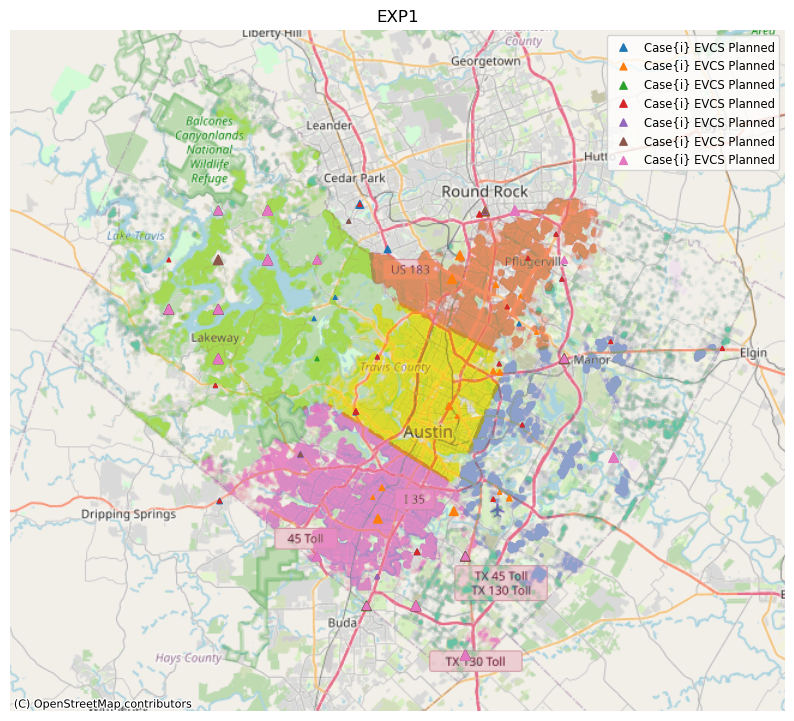

In [ ]:
MasterPaths, BusPaths, subGridPath = compile_dss_files(AusGridPath, masterpath, buscoords_path)

CasesNum = 7

charger_cases = []
for idx in range(CasesNum):
    df_cases = pd.read_csv(f"Cases{EVplanningFolder}/ProcessedEVplanData/EVplanData_case{idx}.csv",usecols=['Extra ports added', 'Longitude', 'Latitude'])
    gdf_cases = gpd.GeoDataFrame(df_cases, geometry=gpd.points_from_xy(df_cases['Longitude'], df_cases['Latitude']), crs="EPSG:4326")
    gdf_cases = gdf_cases.to_crs(epsg=3857)
    charger_cases.append(gdf_cases)



columns = ['Location', 'Longitude', 'Latitude']
# Generate a color palette for the regions
colors = sns.color_palette("Set2", n_colors=len(BusPaths))
fig, ax = plt.subplots(figsize=(10, 10))
for buspathidx in range(len(BusPaths)):
    df = pd.read_csv(BusPaths[buspathidx],delimiter=' ')
    df.columns = columns
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), crs="EPSG:4326")
    gdf = gdf.to_crs(epsg=3857)
    gdf.plot(ax=ax, marker='o', color=colors[buspathidx], markersize=5, label=subGridPath[buspathidx],alpha=0.03)
    # gdf.plot(ax=ax, marker='o', color=colors[buspathidx], markersize=5, alpha=0.01)
colors = sns.color_palette(n_colors=len(charger_cases))
# markers = ['o', 's', '^', 'D', 'x', 'v', '*']
# Plot the EV charger stations
for i,gdf_cases in enumerate(charger_cases):
    # gdf_cases.plot(ax=ax, marker='^', color=colors[i], markersize=gdf_cases['Extra ports added']*8, label='Case{i} EVCS Planned', alpha=1)
    gdf_cases.plot(ax=ax, marker='^',  markersize=gdf_cases['Extra ports added']*8, label='Case{i} EVCS Planned', alpha=1)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title("EXP1")
ax.set_axis_off()
ax.legend(fontsize='small')

In [53]:
def plot_EV_experiment(resultfolder, ax, experiment_label,BusPaths, cases_ports,show_legend=False):
    
    CasesNum = 7

    charger_cases = []
    for idx in range(CasesNum):
        df_cases = pd.read_csv(f"{resultfolder}/ProcessedEVplanData/EVplanData_case{idx}.csv",usecols=['Extra ports added', 'Longitude', 'Latitude'])
        gdf_cases = gpd.GeoDataFrame(df_cases, geometry=gpd.points_from_xy(df_cases['Longitude'], df_cases['Latitude']), crs="EPSG:4326")
        gdf_cases = gdf_cases.to_crs(epsg=3857)
        charger_cases.append(gdf_cases)



    columns = ['Location', 'Longitude', 'Latitude']
    # Generate a color palette for the regions
    colors = sns.color_palette("Set2", n_colors=len(BusPaths))

    for buspathidx in range(len(BusPaths)):
        df = pd.read_csv(BusPaths[buspathidx],delimiter=' ')
        df.columns = columns
        gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), crs="EPSG:4326")
        gdf = gdf.to_crs(epsg=3857)
        # gdf.plot(ax=ax, marker='o', color=colors[buspathidx], markersize=5, label=subGridPath[buspathidx],alpha=0.03)
        gdf.plot(ax=ax, marker='o', color=colors[buspathidx], markersize=5, alpha=0.03)
    colors = sns.color_palette(n_colors=len(charger_cases))
    colors[-1] = (0.1, 0.15, 0.9)#manually set the last color to blue
    # Plot the EV charger stations
    for i,gdf_cases in enumerate(charger_cases):
        # gdf_cases.plot(ax=ax, marker='^', color=colors[i], markersize=gdf_cases['Extra ports added']*8, label='Case{i} EVCS Planned', alpha=1)
        new_ports, existing_ports = cases_ports[i]
        gdf_cases.plot(ax=ax, marker='^', color=colors[i], markersize=gdf_cases['Extra ports added']*8, label=f"({new_ports},{existing_ports})", alpha=1)

    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
    ax.set_title(experiment_label)
    ax.set_axis_off()
    # if show_legend:
    ax.legend(loc = 'lower left',fontsize=14)

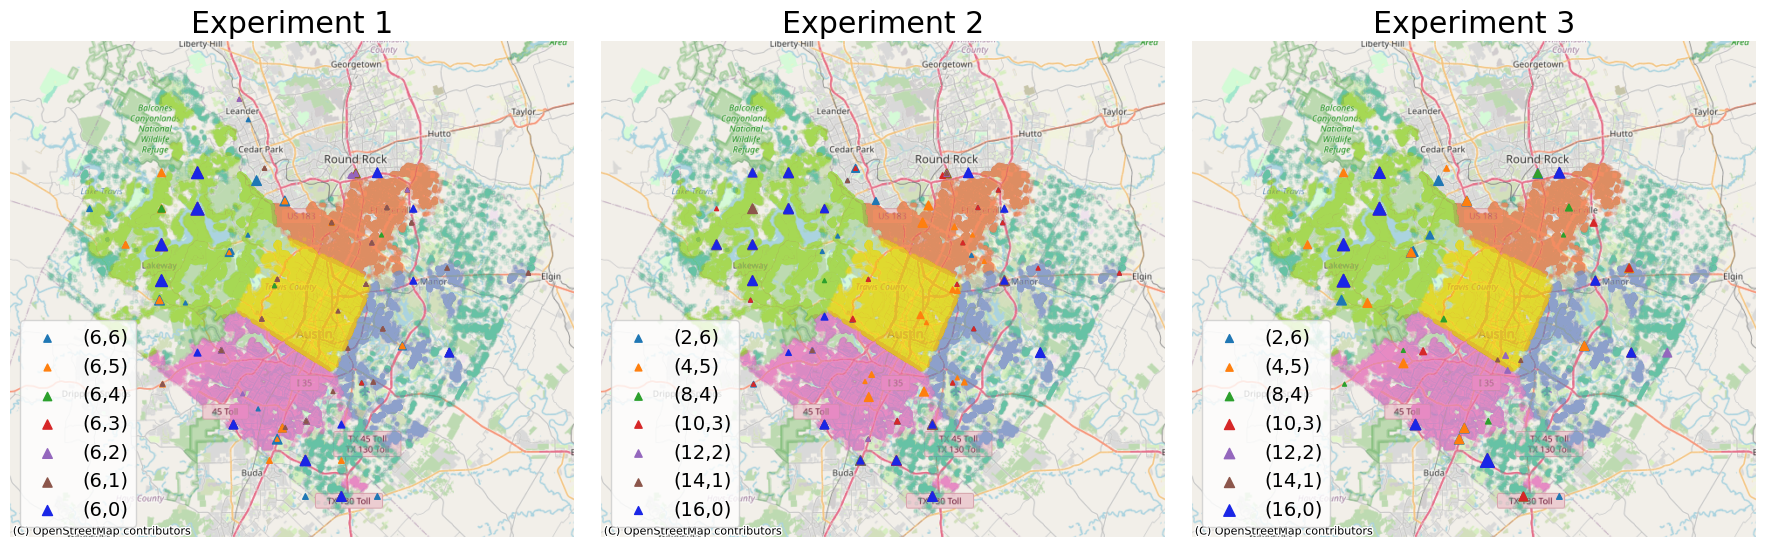

In [ ]:
MasterPaths, BusPaths, subGridPath = compile_dss_files(AusGridPath, masterpath, buscoords_path)

resultfolder = [
    "CaseResults3",
    "CasesResults4",
    "CasesResults5"
]

experiment_label = [
    "Experiment 1",
    "Experiment 2",
    "Experiment 3"
]

cases_ports = {
    "Experiment 1": [(6,6),(6,5),(6,4),(6,3),(6,2),(6,1),(6,0)] ,
    "Experiment 2": [(2,6),(4,5),(8,4),(10,3),(12,2),(14,1),(16,0)], 
    "Experiment 3": [(2,6),(4,5),(8,4),(10,3),(12,2),(14,1),(16,0)]
}

fig, ax = plt.subplots(1,3,figsize=(18, 6))

for i in range(len(resultfolder)):
    get_current_path()
    # show_legend = show_legend=(i==0)
    plot_EV_experiment(resultfolder[i], ax[i], experiment_label[i],BusPaths,cases_ports[experiment_label[i]],show_legend=True)

plt.tight_layout()
plt.savefig("PlotsResults\\EV_planning_experiments.png", dpi=300, bbox_inches='tight')
# plt.savefig("PlotsResults\\EV_planning_experiments.pdf",  bbox_inches='tight',dpi=300)
plt.show()

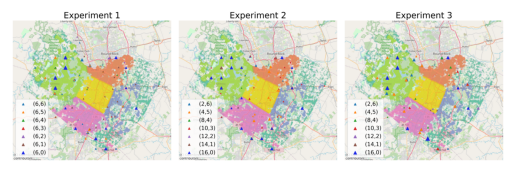

In [70]:
import matplotlib.image as mpimg
img = mpimg.imread("PlotsResults\\EV_planning_experiments.png")
plt.imshow(img)
plt.axis('off')  # Hide the axes
plt.savefig("PlotsResults\\EV_planning_experiments.pdf", bbox_inches='tight', pad_inches=0,dpi=600)
plt.show()

In [59]:
cases_ports = {
    "Experiment 1": [(6,6),(6,5),(6,4),(6,3),(6,2),(6,1),(6,0)] ,
    "Experiment 2": [(2,6),(4,5),(8,4),(10,3),(12,2),(14,1),(16,0)], 
    "Experiment 3": [(2,6),(4,5),(8,4),(10,3),(12,2),(14,1),(16,0)]
}

In [63]:
cases_ports{'Experiment 1'}

SyntaxError: invalid syntax (3068371372.py, line 1)